# Experiment A - Raw-Acceleration CNN Baseline

**Question:** how much character-discriminative information is available in the producer's raw acceleration channels for held-out users?

Strict protocol:

1. Read raw acceleration from `paddedSpikeIMU[..., 15:18]`.
2. Split by **user**, never by segment.
3. Fit normalization using **raw train valid samples only**.
4. Train `MaskAwareAccelerationCNN` from scratch.
5. Select the best epoch using validation balanced accuracy.
6. Evaluate raw held-out test users with the shared representation protocol.
7. Save the authoritative A checkpoint used by B for weights, split, class mapping, and normalization; C/D reuse its split/class mapping.
8. Regenerate Experiment A before running B/C/D whenever `EXCLUDED_USERS`, `INCLUDED_LABELS`, or the selected dataset roots change.

This notebook remains a thin configuration/presentation layer. The executable experiment lives in `scripts/run_experiment_a.py`; reusable implementation lives in `snn/accel_reconstruction_eval/`.

## Visualization additions

The visualization section **does not recompute experimental metrics**. It reads `run` and the standardized artifacts already produced by Experiment A and adds:

- training curves;
- train/validation/test classification comparison;
- kNN model-selection curve;
- SameLabel@K curve;
- task/readout dashboard;
- geometry and unsupervised diagnostics;
- normalized held-out-test confusion matrix;
- PCA projection of test embeddings;
- per-class embedding compactness;
- AP and silhouette distributions.

Figures are also saved under `notebooks/artifacts/acceleration_cnn_representation/figures/`.


In [251]:
from __future__ import annotations

from dataclasses import replace
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


def find_repository_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "scripts").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate repository root containing snn/ and scripts/."
    )


REPOSITORY_ROOT = find_repository_root(Path.cwd())
SCRIPTS_DIR = REPOSITORY_ROOT / "scripts"

if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from snn.accel_reconstruction_eval import experiment_a_config
from run_experiment_a import run_experiment_a

print("Repository root:", REPOSITORY_ROOT)
print("CUDA available:", torch.cuda.is_available())


Repository root: /home/ted/project/writingring-viz
CUDA available: True


## Paths and experiment controls


In [252]:
# Select one root (Action 0 or Action 1), or both roots in this ordered list.
# Roots remain separate on disk and are combined only in the shared loader.
# The runner owns model/training logic; this is the only probe switch needed here.
PROBE_VARIANT = "cnn_l"  # one of: cnn_s, cnn_m, cnn_l
DATASET_ROOTS = [
    Path("outputs/action0_rectified/low-pass/aligned-board-events"),
    Path("outputs/action1_rectified/low-pass/aligned-board-events"),
]
OUTPUT_DIR = Path("notebooks/artifacts/acceleration_cnn_representation")

# Ordered user aliases to exclude from the source cohort; leave empty for all users.
EXCLUDED_USERS = ()

# Ordered labels to retain after user exclusion; None keeps every label.
INCLUDED_LABELS = ("A", "B", "C", "D", "E", "X", "G", "H", "I", "J", "K", "L")

RANDOM_SEED = 12345
NUM_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 30
BATCH_SIZE = 128
NUM_WORKERS = 0
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.0
USE_CLASS_WEIGHTS = False
GRAD_CLIP_NORM = None
MAX_TRAIN_BATCHES = None
USE_GPU = True

# Visualization controls.
PCA_MAX_POINTS = 5000
FIGURE_DPI = 180


## Build the Experiment A configuration

The domain contract is fixed: raw train / raw validation / raw test, with normalization fitted on raw train valid samples only.


In [253]:
config = experiment_a_config(
    output_dir=OUTPUT_DIR,
    random_seed=RANDOM_SEED,
    probe_variant=PROBE_VARIANT,
)
config = replace(
    config,
    split=replace(
        config.split,
        excluded_users=EXCLUDED_USERS,
        included_labels=INCLUDED_LABELS,
    ),
    use_gpu=USE_GPU,
    loader=replace(
        config.loader,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
    ),
    training=replace(
        config.training,
        num_epochs=NUM_EPOCHS,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        use_class_weights=USE_CLASS_WEIGHTS,
        grad_clip_norm=GRAD_CLIP_NORM,
        max_train_batches=MAX_TRAIN_BATCHES,
    ),
    evaluation=replace(
        config.evaluation,
        random_seed=RANDOM_SEED,
    ),
)
config.validate()
config.to_dict()


{'name': 'A_raw',
 'train_source': 'raw',
 'val_source': 'raw',
 'test_source': 'raw',
 'normalization_source': 'raw',
 'probe_variant': 'cnn_l',
 'training_enabled': True,
 'random_seed': 12345,
 'use_gpu': True,
 'normalization_chunk_segments': 256,
 'split': {'train_fraction': 0.7,
  'val_fraction': 0.15,
  'explicit_train_users': None,
  'explicit_val_users': None,
  'explicit_test_users': None,
  'require_all_users_assigned': True,
  'require_all_labels_in_all_splits': True,
  'excluded_users': (),
  'included_labels': ('A',
   'B',
   'C',
   'D',
   'E',
   'X',
   'G',
   'H',
   'I',
   'J',
   'K',
   'L')},
 'loader': {'batch_size': 128,
  'num_workers': 0,
  'pin_memory': None,
  'persistent_workers': None},
 'training': {'num_epochs': 200,
  'learning_rate': 0.0005,
  'weight_decay': 0.0,
  'use_class_weights': False,
  'early_stopping_patience': 30,
  'max_train_batches': None,
  'grad_clip_norm': None},
 'evaluation': {'k_values': (1, 3, 5, 10, 20, 50),
  'knn_k_candidat

## Run Experiment A

`load + validate -> exclude users -> select labels -> user split -> raw normalization -> train -> best validation epoch -> embeddings -> evaluate -> save artifacts`


In [254]:
run = run_experiment_a(
    root=DATASET_ROOTS,
    repository_root=REPOSITORY_ROOT,
    output_dir=OUTPUT_DIR,
    config=config,
    probe_variant=PROBE_VARIANT,
)


Epoch 001 | train loss=2.42039, BA=0.12804 | val loss=2.46069, BA=0.08333
Epoch 002 | train loss=2.23452, BA=0.23408 | val loss=2.39900, BA=0.15896
Epoch 003 | train loss=2.13824, BA=0.28209 | val loss=2.30249, BA=0.23384
Epoch 004 | train loss=2.05873, BA=0.32601 | val loss=2.19356, BA=0.31190
Epoch 005 | train loss=1.98270, BA=0.35863 | val loss=2.11252, BA=0.35076
Epoch 006 | train loss=1.90897, BA=0.39248 | val loss=2.05538, BA=0.31528
Epoch 007 | train loss=1.85366, BA=0.37989 | val loss=1.95213, BA=0.38725
Epoch 008 | train loss=1.78184, BA=0.43868 | val loss=1.93457, BA=0.27980
Epoch 009 | train loss=1.69665, BA=0.50551 | val loss=1.88822, BA=0.35096
Epoch 010 | train loss=1.64089, BA=0.52938 | val loss=1.79831, BA=0.43258
Epoch 011 | train loss=1.57380, BA=0.57515 | val loss=1.79232, BA=0.46860
Epoch 012 | train loss=1.50768, BA=0.61361 | val loss=1.87180, BA=0.27576
Epoch 013 | train loss=1.44273, BA=0.60189 | val loss=1.90180, BA=0.28125
Epoch 014 | train loss=1.40413, BA=0.6

## Authoritative cohort

These fields combine A's provenance with its cohort artifact. Regenerate A before running B/C/D whenever either cohort control changes.


In [255]:
provenance = json.loads(
    (run.output_dir / "provenance.json").read_text(encoding="utf-8")
)
cohort = json.loads(
    (run.output_dir / "cohort.json").read_text(encoding="utf-8")
)

display(
    pd.Series(
        {
            "excluded_users": cohort["excluded_users"],
            "eligible_users": cohort["eligible_users"],
            "train_users": provenance["train_users"],
            "val_users": provenance["val_users"],
            "test_users": provenance["test_users"],
            "class_to_idx": provenance["class_to_idx"],
        },
        name="Experiment A cohort",
    )
)


excluded_users                                                   []
eligible_users    [user_0, user_1, user_2, user_3, user_4, user_...
train_users       [user_0, user_1, user_3, user_4, user_5, user_...
val_users                                [user_8, user_14, user_20]
test_users                               [user_2, user_13, user_16]
class_to_idx      {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'G': ...
Name: Experiment A cohort, dtype: object

## Primary results


In [256]:
display(run.summary.T.rename(columns={0: "Experiment A"}))


,Experiment A
CNN_test_balanced_accuracy,0.593735
CNN_test_accuracy,0.598425
CNN_test_macro_f1,0.561484
kNN_selected_k,20.000000
kNN_test_balanced_accuracy,0.607083
kNN_test_accuracy,0.614173
kNN_test_macro_f1,0.577892
prototype_test_balanced_accuracy,0.572361
prototype_test_accuracy,0.574803
prototype_test_macro_f1,0.540272


## CNN classification across splits


In [257]:
display(run.classification_splits)


,accuracy,balanced_accuracy,macro_f1,weighted_f1,loss
split,,,,,
train,0.981735,0.980853,0.981404,0.981692,0.434625
val,0.606299,0.606710,0.571664,0.569946,1.278920
test,0.598425,0.593735,0.561484,0.565104,1.292841


## Split contract


In [258]:
display(run.split_summary)
display(run.label_split_counts)


,users,samples,labels
split,,,
train,14,657,12
val,3,127,12
test,3,127,12


split,train,val,test
label,,,
A,51,10,11
B,56,10,9
C,60,12,12
D,58,11,11
E,58,10,12
G,52,12,12
H,61,12,12
I,57,12,11
J,58,11,12


## Raw-train normalization


In [259]:
display(
    pd.DataFrame(
        {
            "channel": ["x", "y", "z"],
            "mean": run.normalization.mean,
            "std": run.normalization.std,
        }
    ).assign(
        fitted_on=run.normalization.fitted_on,
        valid_time_points=run.normalization.valid_time_points,
    )
)


,channel,mean,std,fitted_on,valid_time_points
0,x,-0.692537,2.038793,raw:train,202358
1,y,0.173281,1.835576,raw:train,202358
2,z,0.202077,1.830725,raw:train,202358


## Training history


In [260]:
display(run.training_history.tail(20))


,epoch,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,loss
118,60,train,1.000000,1.000000,1.000000,1.000000,0.113663
119,60,val,0.456693,0.445518,0.396504,0.408694,1.693712
120,61,train,1.000000,1.000000,1.000000,1.000000,0.095094
121,61,val,0.559055,0.557846,0.554143,0.547138,1.306130
122,62,train,1.000000,1.000000,1.000000,1.000000,0.102323
123,62,val,0.503937,0.485669,0.433230,0.450679,1.488273
124,63,train,0.998478,0.998634,0.998502,0.998479,0.092141
125,63,val,0.433071,0.423936,0.404230,0.409315,1.440879
126,64,train,0.998478,0.998563,0.998538,0.998478,0.083133
127,64,val,0.582677,0.590864,0.545646,0.539308,1.324886


# Visualization

The cells below are presentation-only. They consume the metrics and embeddings already generated by `run_experiment_a()`.

A useful reading order is:

1. **training dynamics** — did optimization converge and where was the selected checkpoint?
2. **split metrics** — how large is the generalization gap?
3. **representation readouts** — can the 256-D embedding recover labels under multiple simple readouts?
4. **geometry** — are same-label samples compact and different labels separated?
5. **confusion/PCA/per-class diagnostics** — which labels remain difficult and how is the held-out-user representation structured?


In [261]:
FIGURE_DIR = run.output_dir / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

summary_row = run.summary.iloc[0].copy()
class_to_idx = {str(k): int(v) for k, v in provenance["class_to_idx"].items()}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}
num_classes = len(class_to_idx)

test_embedding_path = run.artifact_paths["embeddings_test"]
knn_validation_path = run.artifact_paths["evaluation_knn_validation"]
same_label_path = run.artifact_paths["evaluation_same_label"]
intra_by_class_path = run.artifact_paths["evaluation_intra_by_class"]
evaluation_arrays_path = run.artifact_paths["evaluation_arrays"]

def save_figure(fig, filename: str) -> Path:
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    print("Saved:", path)
    plt.show()
    return path

def annotate_bars(ax, fmt="{:.3f}"):
    for patch in ax.patches:
        height = patch.get_height()
        if np.isfinite(height):
            ax.annotate(
                fmt.format(height),
                (patch.get_x() + patch.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
            )

print("Figure directory:", FIGURE_DIR)


Figure directory: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures


## 1. Training dynamics

The best model is selected using **validation balanced accuracy**. The vertical marker should coincide with the best validation checkpoint rather than simply the last epoch.


Saved: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/01_training_loss.png


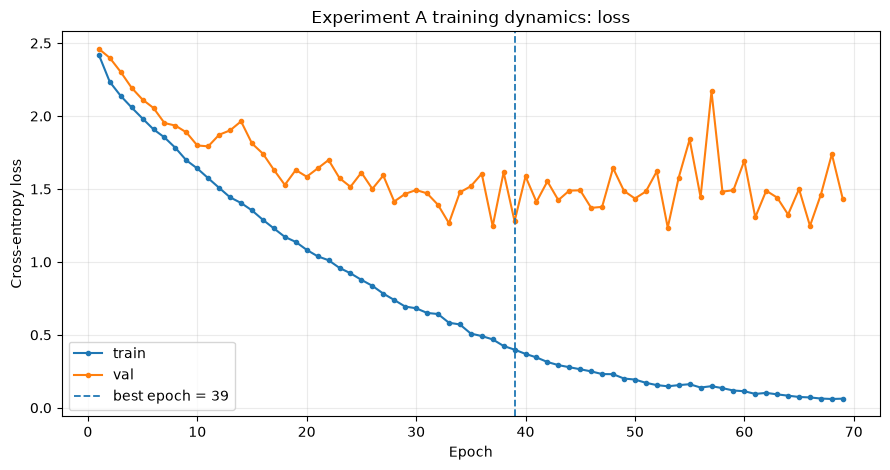

PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/01_training_loss.png')

In [262]:
history = run.training_history.copy()
best_epoch = int(provenance["best_epoch"])
best_val_ba = float(provenance["best_val_balanced_accuracy"])

loss_table = history.pivot(index="epoch", columns="split", values="loss")
fig, ax = plt.subplots(figsize=(9, 4.8))
for split_name in loss_table.columns:
    ax.plot(
        loss_table.index,
        loss_table[split_name],
        marker="o",
        markersize=3,
        label=split_name,
    )
ax.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.3,
    label=f"best epoch = {best_epoch}",
)
ax.set_title("Experiment A training dynamics: loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
save_figure(fig, "01_training_loss.png")


Saved: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/02_training_balanced_accuracy.png


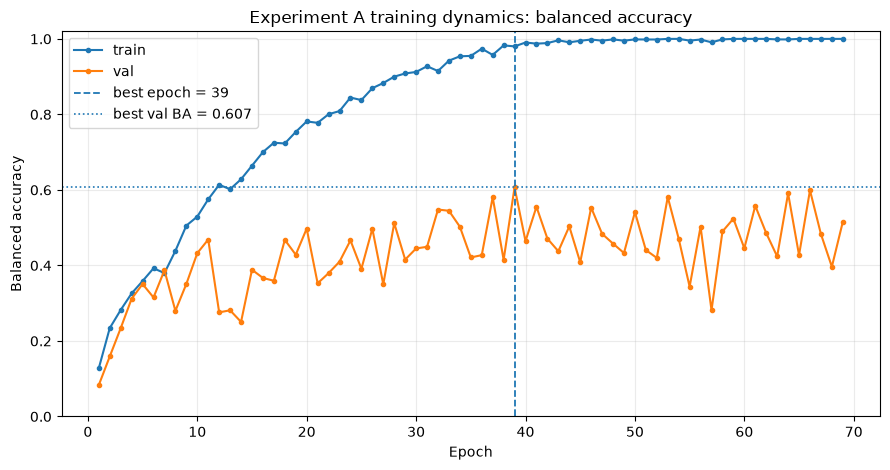

PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/02_training_balanced_accuracy.png')

In [263]:
ba_table = history.pivot(
    index="epoch",
    columns="split",
    values="balanced_accuracy",
)
fig, ax = plt.subplots(figsize=(9, 4.8))
for split_name in ba_table.columns:
    ax.plot(
        ba_table.index,
        ba_table[split_name],
        marker="o",
        markersize=3,
        label=split_name,
    )
ax.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.3,
    label=f"best epoch = {best_epoch}",
)
ax.axhline(
    best_val_ba,
    linestyle=":",
    linewidth=1.2,
    label=f"best val BA = {best_val_ba:.3f}",
)
ax.set_title("Experiment A training dynamics: balanced accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Balanced accuracy")
ax.set_ylim(0.0, 1.02)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
save_figure(fig, "02_training_balanced_accuracy.png")


## 2. Cross-user generalization across train / validation / test

This plot makes the held-out-user generalization gap visible. Large train-to-test gaps suggest user-specific overfitting even when raw acceleration is informative.


Saved: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/03_classification_across_splits.png


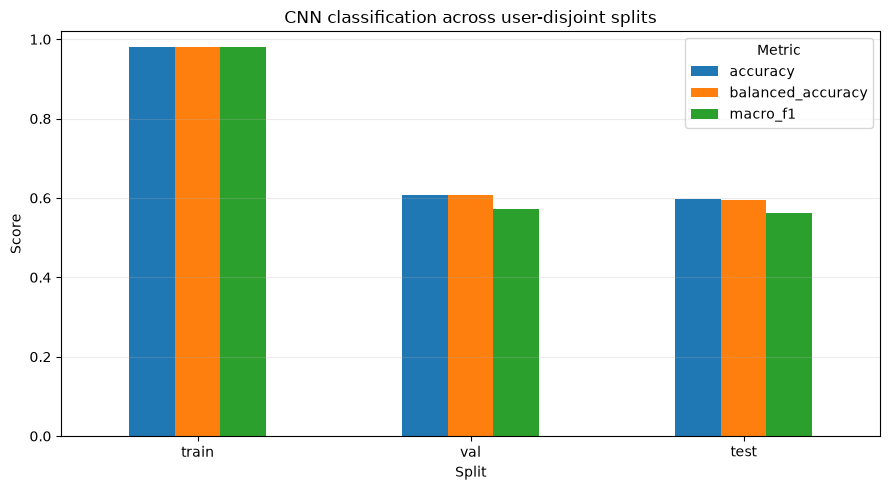

PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/03_classification_across_splits.png')

In [264]:
split_plot = run.classification_splits[
    ["accuracy", "balanced_accuracy", "macro_f1"]
].copy()

fig, ax = plt.subplots(figsize=(9, 5))
split_plot.plot(kind="bar", ax=ax)
ax.set_title("CNN classification across user-disjoint splits")
ax.set_xlabel("Split")
ax.set_ylabel("Score")
ax.set_ylim(0.0, 1.02)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Metric")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
save_figure(fig, "03_classification_across_splits.png")


## 3. kNN K selection on validation users

`K` is chosen using validation users only. This plot shows whether the selected neighborhood size is stable or whether performance is highly sensitive to K.


,k,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,1,0.566929,0.574829,0.555526,0.546233
1,3,0.574803,0.583856,0.564468,0.554450
2,5,0.622047,0.630195,0.609563,0.600646
3,7,0.622047,0.627480,0.611246,0.603870
4,10,0.606299,0.612834,0.595577,0.587445
5,15,0.606299,0.613591,0.595730,0.587079
6,20,0.629921,0.635056,0.615687,0.607530


Saved: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/04_knn_validation_selection.png


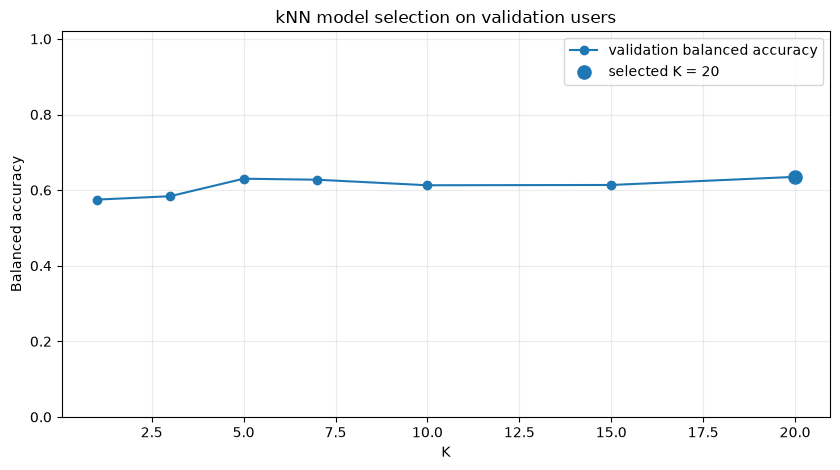

PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/04_knn_validation_selection.png')

In [265]:
knn_validation = pd.read_csv(knn_validation_path)
display(knn_validation)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(
    knn_validation["k"],
    knn_validation["balanced_accuracy"],
    marker="o",
    label="validation balanced accuracy",
)
selected_k = int(summary_row["kNN_selected_k"])
selected_row = knn_validation.loc[knn_validation["k"] == selected_k]
if len(selected_row) == 1:
    selected_score = float(selected_row.iloc[0]["balanced_accuracy"])
    ax.scatter([selected_k], [selected_score], s=90, label=f"selected K = {selected_k}")
ax.set_title("kNN model selection on validation users")
ax.set_xlabel("K")
ax.set_ylabel("Balanced accuracy")
ax.set_ylim(0.0, 1.02)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
save_figure(fig, "04_knn_validation_selection.png")


## 4. SameLabel@K neighborhood purity

Higher SameLabel@K means held-out-user test embeddings are surrounded by training embeddings with the same label. Macro and micro views are shown together.


,k,same_label_micro,same_label_macro
0,1,0.535433,0.518128
1,3,0.545932,0.533901
2,5,0.557480,0.551732
3,10,0.566929,0.559232
4,20,0.546457,0.537865
5,50,0.487244,0.479042


Saved: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/05_same_label_at_k.png


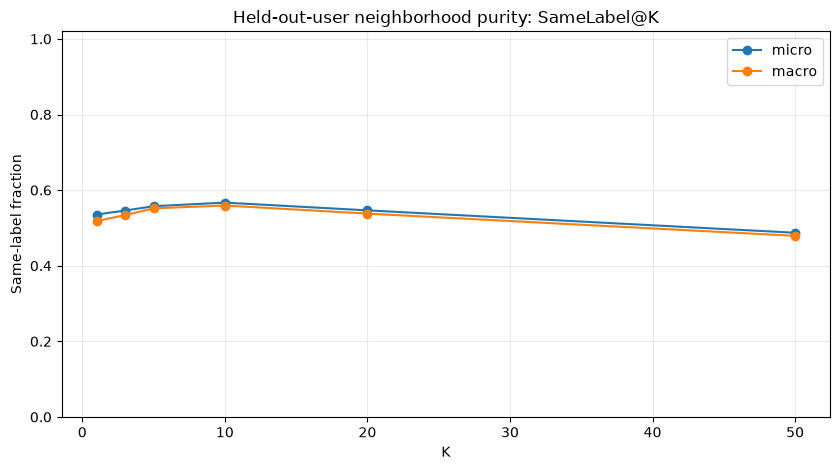

PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/05_same_label_at_k.png')

In [266]:
same_label = pd.read_csv(same_label_path)
display(same_label)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(
    same_label["k"],
    same_label["same_label_micro"],
    marker="o",
    label="micro",
)
ax.plot(
    same_label["k"],
    same_label["same_label_macro"],
    marker="o",
    label="macro",
)
ax.set_title("Held-out-user neighborhood purity: SameLabel@K")
ax.set_xlabel("K")
ax.set_ylabel("Same-label fraction")
ax.set_ylim(0.0, 1.02)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
save_figure(fig, "05_same_label_at_k.png")


## 5. Main task/readout dashboard

These scores answer slightly different questions:

- **CNN BA / Macro-F1**: performance of the trained nonlinear classifier.
- **kNN BA**: local label structure in the embedding.
- **Prototype BA**: separation around train-domain class centroids.
- **Linear probe BA**: linearly recoverable label information.
- **macro mAP / SameLabel@1**: retrieval and local neighborhood quality.

All are on a common 0–1 scale and can therefore be compared visually.


,score
CNN BA,0.593735
CNN Macro-F1,0.561484
kNN BA,0.607083
Prototype BA,0.572361
Linear probe BA,0.557840
Retrieval macro mAP,0.512482
SameLabel@1 macro,0.518128


Saved: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/06_representation_readout_dashboard.png


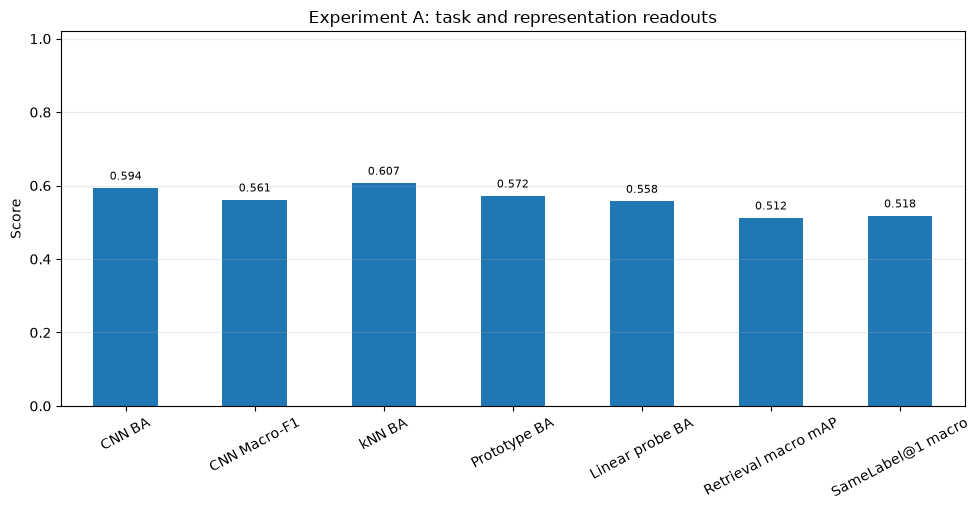

PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/06_representation_readout_dashboard.png')

In [267]:
readout_keys = [
    ("CNN BA", "CNN_test_balanced_accuracy"),
    ("CNN Macro-F1", "CNN_test_macro_f1"),
    ("kNN BA", "kNN_test_balanced_accuracy"),
    ("Prototype BA", "prototype_test_balanced_accuracy"),
    ("Linear probe BA", "linear_probe_test_balanced_accuracy"),
    ("Retrieval macro mAP", "retrieval_macro_mAP"),
    ("SameLabel@1 macro", "SameLabel_macro_at_1"),
]

readout_scores = pd.Series(
    {label: float(summary_row[key]) for label, key in readout_keys},
    name="score",
)
display(readout_scores.to_frame())

fig, ax = plt.subplots(figsize=(10, 5.2))
readout_scores.plot(kind="bar", ax=ax)
ax.set_title("Experiment A: task and representation readouts")
ax.set_ylabel("Score")
ax.set_ylim(0.0, 1.02)
ax.tick_params(axis="x", rotation=28)
ax.grid(axis="y", alpha=0.25)
annotate_bars(ax)
fig.tight_layout()
save_figure(fig, "06_representation_readout_dashboard.png")


## 6. Embedding geometry

Interpret these jointly:

- lower `D_intra` = tighter same-label clusters;
- higher `D_inter` = more separated class centroids;
- higher `D_inter / D_intra` = stronger relative separation.

The ratio should **not** be interpreted without the two components.


,value
D_intra,0.062928
D_inter,0.087044
D_inter / D_intra,1.383227


Saved: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/07_embedding_geometry.png


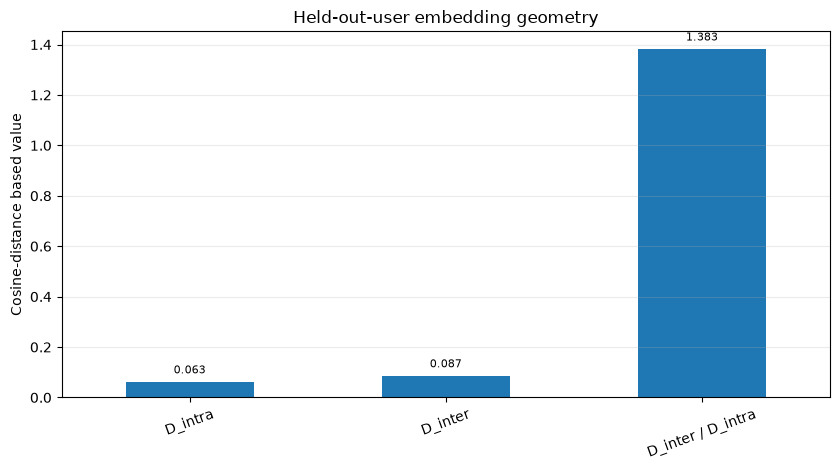

PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/07_embedding_geometry.png')

In [268]:
geometry_scores = pd.Series(
    {
        "D_intra": float(summary_row["D_intra_macro"]),
        "D_inter": float(summary_row["D_inter_centroids"]),
        "D_inter / D_intra": float(summary_row["D_inter_over_D_intra"]),
    },
    name="value",
)
display(geometry_scores.to_frame())

fig, ax = plt.subplots(figsize=(8.5, 4.8))
geometry_scores.plot(kind="bar", ax=ax)
ax.set_title("Held-out-user embedding geometry")
ax.set_ylabel("Cosine-distance based value")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)
annotate_bars(ax)
fig.tight_layout()
save_figure(fig, "07_embedding_geometry.png")


## 7. Unsupervised label/cluster alignment

NMI and ARI measure agreement between KMeans clusters and true labels without using labels to fit the clustering. Cosine silhouette measures how well each sample fits its own label cluster relative to competing labels.


,score
NMI,0.619996
ARI,0.339385
Silhouette macro,0.095194
Silhouette micro,0.088618


Saved: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/08_unsupervised_embedding_quality.png


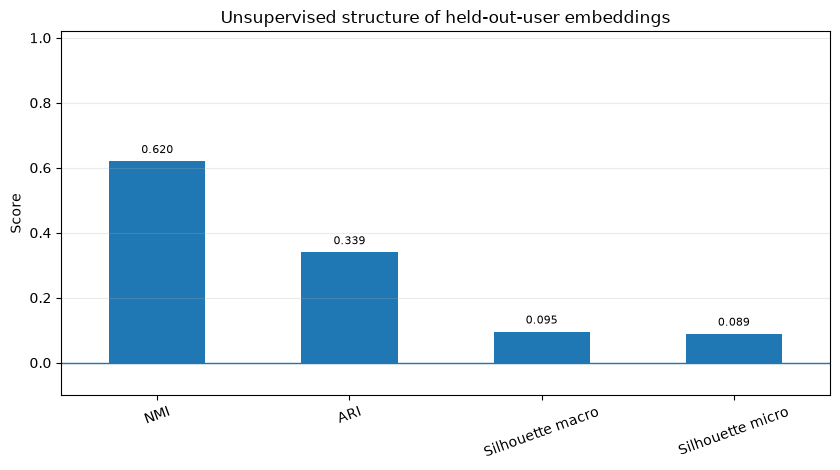

PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/08_unsupervised_embedding_quality.png')

In [269]:
unsupervised_scores = pd.Series(
    {
        "NMI": float(summary_row["NMI_arithmetic"]),
        "ARI": float(summary_row["ARI"]),
        "Silhouette macro": float(summary_row["silhouette_macro"]),
        "Silhouette micro": float(summary_row["silhouette_micro"]),
    },
    name="score",
)
display(unsupervised_scores.to_frame())

fig, ax = plt.subplots(figsize=(8.5, 4.8))
unsupervised_scores.plot(kind="bar", ax=ax)
ax.axhline(0.0, linewidth=1.0)
ax.set_title("Unsupervised structure of held-out-user embeddings")
ax.set_ylabel("Score")
ax.set_ylim(
    min(-0.1, float(unsupervised_scores.min()) - 0.05),
    1.02,
)
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)
annotate_bars(ax)
fig.tight_layout()
save_figure(fig, "08_unsupervised_embedding_quality.png")


## 8. Normalized held-out-test confusion matrix

Rows are true labels and columns are CNN predictions. Row normalization makes minority classes directly comparable to majority classes.


Saved: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/09_test_confusion_matrix_normalized.png


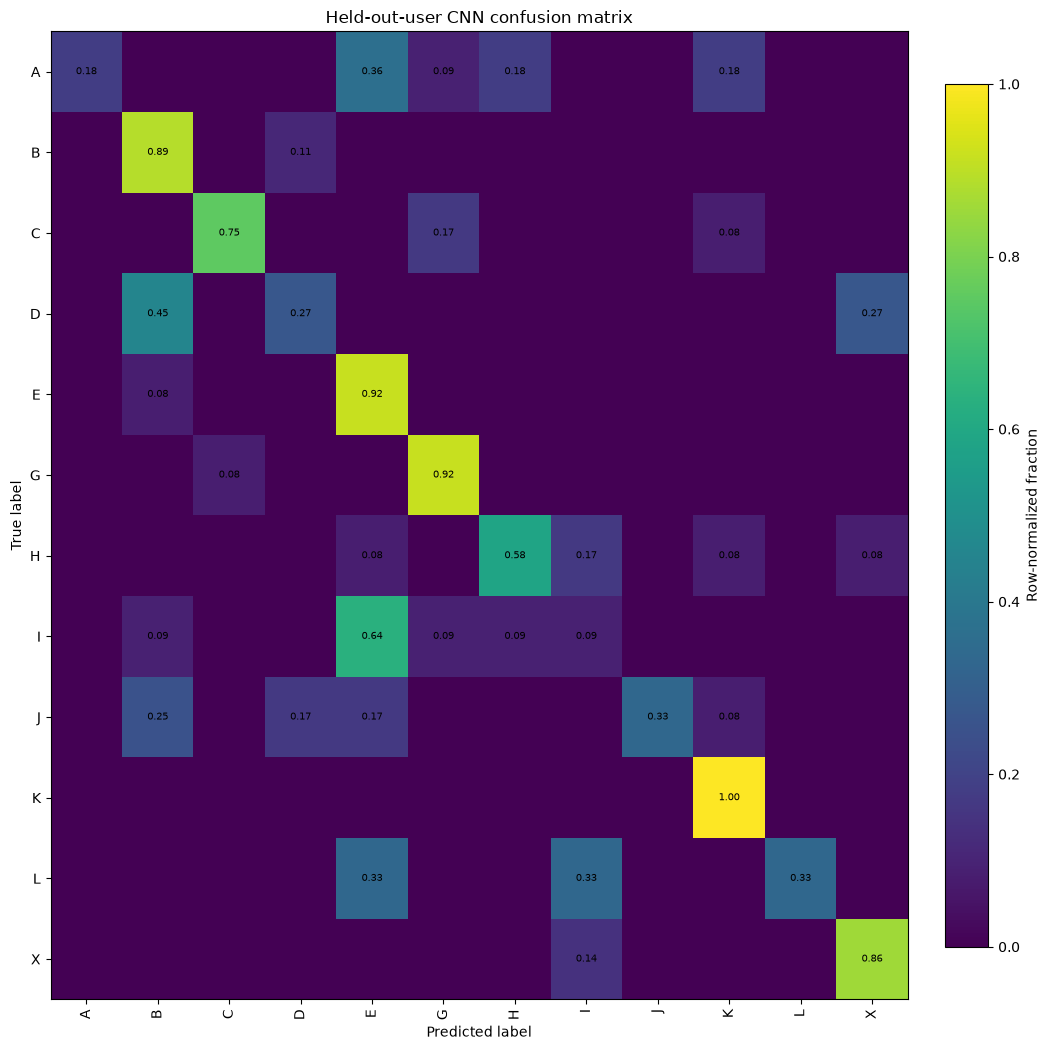

PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/09_test_confusion_matrix_normalized.png')

In [270]:
with np.load(test_embedding_path, allow_pickle=False) as values:
    test_y = values["y"].astype(np.int64)
    test_pred = values["cnn_pred"].astype(np.int64)
    test_z = values["z"].astype(np.float32)

confusion = np.zeros((num_classes, num_classes), dtype=np.int64)
np.add.at(confusion, (test_y, test_pred), 1)

row_totals = confusion.sum(axis=1, keepdims=True)
confusion_normalized = np.divide(
    confusion,
    row_totals,
    out=np.zeros_like(confusion, dtype=np.float64),
    where=row_totals > 0,
)

tick_labels = [idx_to_class.get(i, str(i)) for i in range(num_classes)]
side = max(7.0, min(18.0, 0.55 * num_classes + 4.0))

fig, ax = plt.subplots(figsize=(side, side))
image = ax.imshow(
    confusion_normalized,
    vmin=0.0,
    vmax=1.0,
    aspect="auto",
)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Row-normalized fraction")

ax.set_title("Held-out-user CNN confusion matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(tick_labels, rotation=90)
ax.set_yticklabels(tick_labels)

if num_classes <= 20:
    for i in range(num_classes):
        for j in range(num_classes):
            value = confusion_normalized[i, j]
            if value >= 0.01:
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7)

fig.tight_layout()
save_figure(fig, "09_test_confusion_matrix_normalized.png")


## 9. PCA view of the 256-D held-out-test embedding

PCA is used **only for visualization**; none of the reported experiment metrics depend on this projection.

To keep the notebook responsive on large test sets, at most `PCA_MAX_POINTS` points are plotted with approximately balanced per-class sampling.


Saved: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/10_test_embedding_pca.png


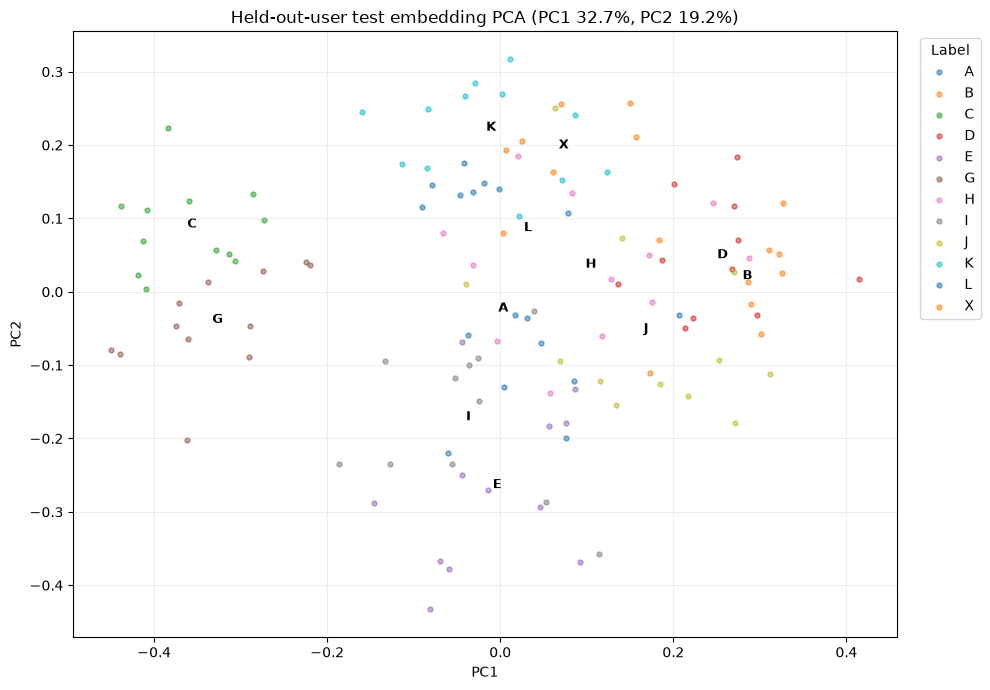

PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/10_test_embedding_pca.png')

In [271]:
rng = np.random.default_rng(RANDOM_SEED)

def balanced_subsample_indices(labels: np.ndarray, max_points: int) -> np.ndarray:
    labels = np.asarray(labels, dtype=np.int64)
    classes = np.unique(labels)
    if len(labels) <= max_points:
        return np.arange(len(labels))

    per_class = max(1, max_points // len(classes))
    selected = []
    leftovers = []

    for class_idx in classes:
        class_indices = np.flatnonzero(labels == class_idx)
        rng.shuffle(class_indices)
        selected.extend(class_indices[:per_class].tolist())
        leftovers.extend(class_indices[per_class:].tolist())

    remaining = max_points - len(selected)
    if remaining > 0 and leftovers:
        leftovers = np.asarray(leftovers, dtype=np.int64)
        rng.shuffle(leftovers)
        selected.extend(leftovers[:remaining].tolist())

    return np.asarray(sorted(selected), dtype=np.int64)


pca_indices = balanced_subsample_indices(test_y, PCA_MAX_POINTS)
pca_x = test_z[pca_indices].astype(np.float64)
pca_y = test_y[pca_indices]

centered = pca_x - pca_x.mean(axis=0, keepdims=True)
_, singular_values, vh = np.linalg.svd(centered, full_matrices=False)
coords = centered @ vh[:2].T

variance = singular_values**2
explained = variance[:2] / variance.sum()

fig, ax = plt.subplots(figsize=(10, 7))
for class_idx in np.unique(pca_y):
    selected = pca_y == class_idx
    label_name = idx_to_class.get(int(class_idx), str(class_idx))
    ax.scatter(
        coords[selected, 0],
        coords[selected, 1],
        s=13,
        alpha=0.55,
        label=label_name,
    )

    centroid = coords[selected].mean(axis=0)
    ax.text(
        centroid[0],
        centroid[1],
        label_name,
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "Held-out-user test embedding PCA "
    f"(PC1 {explained[0]:.1%}, PC2 {explained[1]:.1%})"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.2)

if num_classes <= 12:
    ax.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
save_figure(fig, "10_test_embedding_pca.png")


## 10. Per-class embedding compactness

`intra_cosine_distance` is lower when test embeddings for a label are more compact. Labels with the largest values are candidates for targeted error analysis.


,label_idx,label,test_samples,intra_cosine_distance
0,0,A,11,0.078091
1,1,B,9,0.040052
2,2,C,12,0.064059
3,3,D,11,0.061718
4,4,E,12,0.057863
5,5,G,12,0.051027
6,6,H,12,0.078338
7,7,I,11,0.067333
8,8,J,12,0.072781
9,9,K,12,0.053163


Saved: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/11_per_class_intra_distance.png


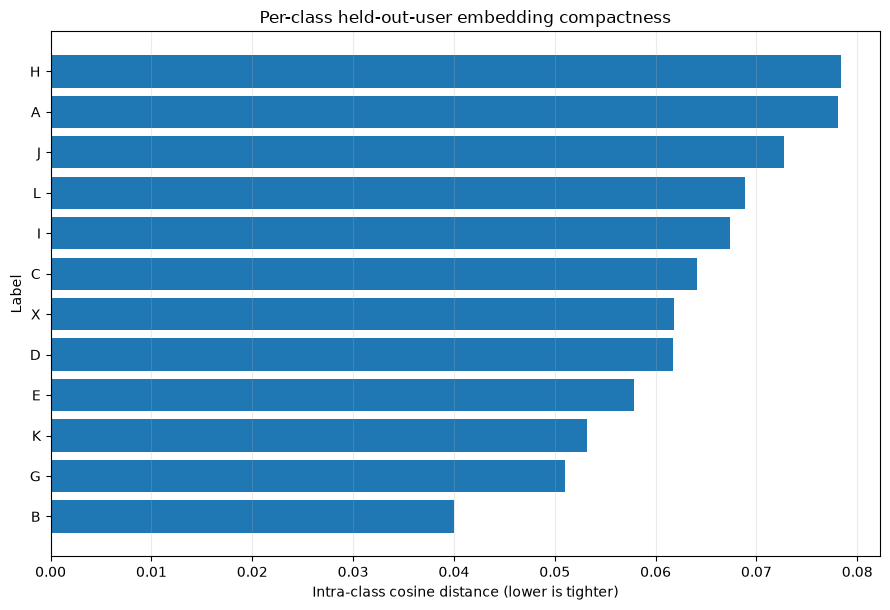

PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/11_per_class_intra_distance.png')

In [272]:
intra_by_class = pd.read_csv(intra_by_class_path)
display(intra_by_class)

intra_sorted = intra_by_class.sort_values(
    "intra_cosine_distance",
    ascending=False,
).reset_index(drop=True)

height = max(4.5, min(14.0, 0.35 * len(intra_sorted) + 2.0))
fig, ax = plt.subplots(figsize=(9, height))
ax.barh(
    intra_sorted["label"].astype(str),
    intra_sorted["intra_cosine_distance"],
)
ax.invert_yaxis()
ax.set_title("Per-class held-out-user embedding compactness")
ax.set_xlabel("Intra-class cosine distance (lower is tighter)")
ax.set_ylabel("Label")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
save_figure(fig, "11_per_class_intra_distance.png")


## 11. Per-query retrieval AP distribution

The macro mAP summary can hide difficult individual samples. The distribution below shows how consistently the representation retrieves same-label training examples.


Saved: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/12_average_precision_distribution.png


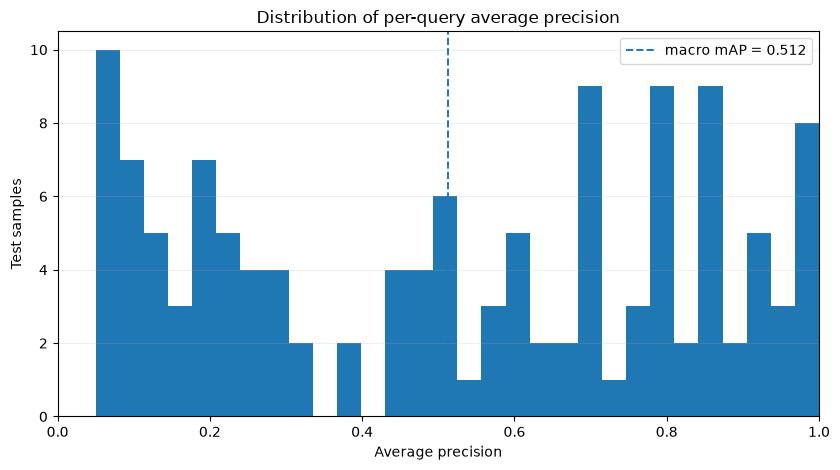

PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/12_average_precision_distribution.png')

In [273]:
with np.load(evaluation_arrays_path, allow_pickle=False) as values:
    average_precision = values["average_precision"].astype(np.float64)
    silhouette_values = values["silhouette_values"].astype(np.float64)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.hist(average_precision, bins=30)
ax.axvline(
    float(summary_row["retrieval_macro_mAP"]),
    linestyle="--",
    linewidth=1.4,
    label=f"macro mAP = {float(summary_row['retrieval_macro_mAP']):.3f}",
)
ax.set_title("Distribution of per-query average precision")
ax.set_xlabel("Average precision")
ax.set_ylabel("Test samples")
ax.set_xlim(0.0, 1.0)
ax.grid(axis="y", alpha=0.2)
ax.legend()
fig.tight_layout()
save_figure(fig, "12_average_precision_distribution.png")


## 12. Cosine silhouette distribution

A positive silhouette means a sample is closer, in aggregate, to its own label cluster than to competing label clusters. Negative tails are useful for locating representation failures that a single mean cannot reveal.


Saved: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/13_silhouette_distribution.png


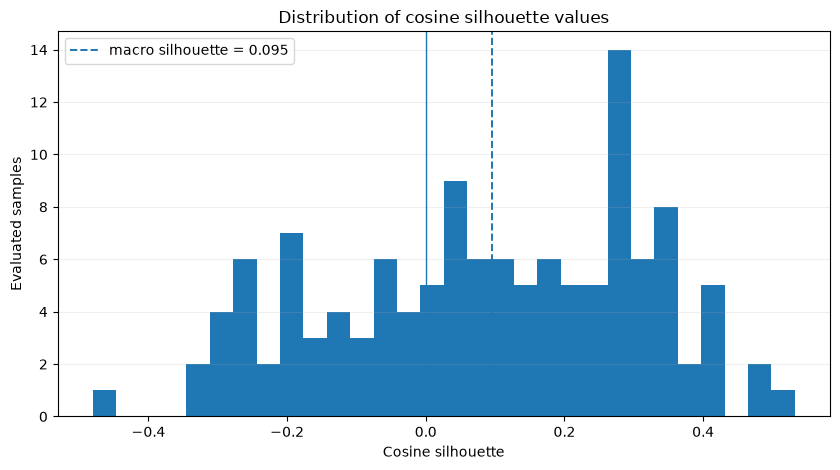

PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation/cnn_l/figures/13_silhouette_distribution.png')

In [274]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.hist(silhouette_values, bins=30)
ax.axvline(
    float(summary_row["silhouette_macro"]),
    linestyle="--",
    linewidth=1.4,
    label=f"macro silhouette = {float(summary_row['silhouette_macro']):.3f}",
)
ax.axvline(0.0, linewidth=1.0)
ax.set_title("Distribution of cosine silhouette values")
ax.set_xlabel("Cosine silhouette")
ax.set_ylabel("Evaluated samples")
ax.grid(axis="y", alpha=0.2)
ax.legend()
fig.tight_layout()
save_figure(fig, "13_silhouette_distribution.png")


## Visualization summary

Use the plots together rather than treating any single metric as definitive:

- high held-out **CNN BA** establishes the raw-acceleration baseline;
- agreement among **kNN / prototype / linear probe** supports a genuinely label-structured embedding rather than a classifier-head-only effect;
- low `D_intra` together with maintained/high `D_inter` supports class separation;
- **SameLabel@K** and **mAP** show local and ranking-based retrieval quality;
- **NMI / ARI / silhouette** test whether structure persists without supervised readout;
- confusion, PCA, and per-class compactness expose label-specific failure modes.

Experiment A should still be interpreted primarily as the authoritative raw-domain baseline for subsequent B/C/D comparisons.


## Saved artifacts


In [275]:
artifact_table = pd.DataFrame(
    [
        {"artifact": name, "path": str(path)}
        for name, path in sorted(run.artifact_paths.items())
    ]
)
display(artifact_table)

figure_table = pd.DataFrame(
    {
        "figure": sorted(path.name for path in FIGURE_DIR.glob("*.png")),
    }
)
display(figure_table)


,artifact,path
0,checkpoint,/home/ted/project/writingring-viz/notebooks/ar...
1,classification_splits,/home/ted/project/writingring-viz/notebooks/ar...
2,cohort,/home/ted/project/writingring-viz/notebooks/ar...
3,embeddings_test,/home/ted/project/writingring-viz/notebooks/ar...
4,embeddings_train,/home/ted/project/writingring-viz/notebooks/ar...
5,embeddings_val,/home/ted/project/writingring-viz/notebooks/ar...
6,evaluation_arrays,/home/ted/project/writingring-viz/notebooks/ar...
7,evaluation_geometry,/home/ted/project/writingring-viz/notebooks/ar...
8,evaluation_intra_by_class,/home/ted/project/writingring-viz/notebooks/ar...
9,evaluation_knn_validation,/home/ted/project/writingring-viz/notebooks/ar...


,figure
0,01_training_loss.png
1,02_training_balanced_accuracy.png
2,03_classification_across_splits.png
3,04_knn_validation_selection.png
4,05_same_label_at_k.png
5,06_representation_readout_dashboard.png
6,07_embedding_geometry.png
7,08_unsupervised_embedding_quality.png
8,09_test_confusion_matrix_normalized.png
9,10_test_embedding_pca.png


## Interpretation

Experiment A is the raw-input reference condition. Interpret B/C/D relative to this run only when they reuse the same user split, class mapping, CNN architecture, and shared metric implementation.
